In [121]:
import pandas as pd
import numpy as np

In [122]:
data = pd.read_csv('train.csv')
data

,response,make,address,all,num3d,our,over,remove,internet,order,...,conference,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal
0,1,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.0,0.925,0.000,0.000,1.833,6,11
1,2,0.00,0.0,0.00,0.0,2.94,0.00,0.0,0.00,0.0,...,0.0,0.335,0.335,0.0,0.671,0.000,0.000,4.000,12,28
2,2,0.00,0.0,1.15,0.0,0.38,0.38,0.0,0.00,0.0,...,0.0,0.000,0.196,0.0,0.261,0.000,0.000,5.666,56,272
3,2,0.10,0.3,0.40,0.0,0.20,0.90,0.2,0.50,0.8,...,0.0,0.000,0.175,0.0,0.307,0.175,0.014,6.937,669,1214
4,1,0.10,0.0,0.00,0.0,0.00,0.10,0.0,0.52,0.0,...,0.0,0.027,0.138,0.0,0.041,0.041,0.000,2.321,31,469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3096,2,0.00,0.0,0.00,0.0,1.35,0.45,0.0,0.00,0.0,...,0.0,0.000,0.138,0.0,0.138,0.000,0.000,5.809,46,122
3097,1,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.0,0.000,0.000,0.000,1.718,11,55
3098,2,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,0.147,0.000,0.0,0.294,0.147,0.000,2.333,11,63
3099,1,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.0,0.000,0.000,0.000,5.500,10,11


In [123]:
y = data.response
y = np.where(y == 1, 0, 1)
y

array([0, 1, 1, ..., 1, 0, 0])

In [124]:
X = data.iloc[:,1:]
# print(X.to_string())
X = np.hstack([np.ones((X.shape[0], 1)), X])
X

array([[  1.   ,   0.   ,   0.   , ...,   1.833,   6.   ,  11.   ],
       [  1.   ,   0.   ,   0.   , ...,   4.   ,  12.   ,  28.   ],
       [  1.   ,   0.   ,   0.   , ...,   5.666,  56.   , 272.   ],
       ...,
       [  1.   ,   0.   ,   0.   , ...,   2.333,  11.   ,  63.   ],
       [  1.   ,   0.   ,   0.   , ...,   5.5  ,  10.   ,  11.   ],
       [  1.   ,   0.56 ,   0.   , ...,   1.23 ,   4.   ,  32.   ]])

In [125]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_prob(X, beta):
    return sigmoid(np.dot(X, beta))

def newton_method(X, y, tol=1e-6, max_iter=100):
    beta = np.zeros(X.shape[1])  # Initialize beta as zeros
    for _ in range(max_iter):
        p = predict_prob(X, beta)
        gradient = X.T @ (y - p)  # First derivative
        W = np.diag(p * (1 - p))  # Hessian diagonal elements
        H = -X.T @ W @ X  # Hessian matrix
        beta_new = beta - np.linalg.inv(H) @ gradient  # Newton-Raphson step
        if np.linalg.norm(beta_new - beta) < tol:  # Convergence check
            break
        beta = beta_new
    return beta

def mm_algorithm(X, y, tol=1e-6, max_iter=100):
    beta = np.zeros(X.shape[1])
    XT_X_inv = np.linalg.inv(4 * X.T @ X)  # Compute once
    for _ in range(max_iter):
        p = predict_prob(X, beta)
        gradient = X.T @ (y - p)
        beta_new = beta + XT_X_inv @ gradient
        if np.linalg.norm(beta_new - beta) < tol:
            break
        beta = beta_new
    return beta

In [126]:
beta_newton = newton_method(X, y)
beta_mm = mm_algorithm(X, y)

In [127]:
beta_newton

array([-1.58089921e+00, -2.51617110e-01, -1.65564101e-01,  3.37805858e-03,
        1.43752622e+00,  6.40793821e-01,  6.28172188e-01,  2.15008638e+00,
        5.98991797e-01,  5.91842895e-01,  7.66488462e-02, -3.53282848e-01,
       -1.80839235e-01, -3.05615421e-02,  1.75452876e-02,  1.35105495e+00,
        1.39619108e+00,  7.52254880e-01,  1.22700104e-01,  8.18592059e-02,
        1.12175860e+00,  2.08615786e-01,  1.53869610e-01,  1.94152961e+00,
        3.93463946e-01, -2.95793072e+00, -6.60339257e-01, -6.04133202e+00,
        4.90805065e-01, -2.59224949e+00, -9.52718313e-02, -3.98973739e+00,
        1.52757735e+00, -7.77688685e-01,  9.17546201e-01, -2.21911818e+00,
        7.83213618e-01,  9.26064877e-03,  1.10713544e+00, -8.47899416e-01,
       -1.51375138e-01, -5.33564482e+01, -2.93912621e+00, -1.50006927e+00,
       -2.23887014e+00, -7.97952207e-01, -1.30561939e+00, -1.98844508e+00,
       -3.78933605e+00, -1.22011739e+00, -3.56977014e-01, -1.41591804e+00,
        2.36654936e-01,  

In [128]:
import numpy as np

# Function to compute FPR and FNR
def calculate_fpr_fnr(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)  # Classify based on threshold
    
    TP = ((y_true == 1) & (y_pred == 1)).sum()  # True Positives
    TN = ((y_true == 0) & (y_pred == 0)).sum()  # True Negatives
    FP = ((y_true == 0) & (y_pred == 1)).sum()  # False Positives
    FN = ((y_true == 1) & (y_pred == 0)).sum()  # False Negatives
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False positive rate
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # False negative rate
    
    return FPR, FNR

# Generate FPR & FNR for multiple thresholds
thresholds = np.linspace(0.01, 0.99, 50)  # Define threshold range
fpr_list, fnr_list = [], []
y_prob = predict_prob(X, beta_newton)

for t in thresholds:
    fpr, fnr = calculate_fpr_fnr(y, y_prob, t)
    fpr_list.append(fpr)
    fnr_list.append(fnr)

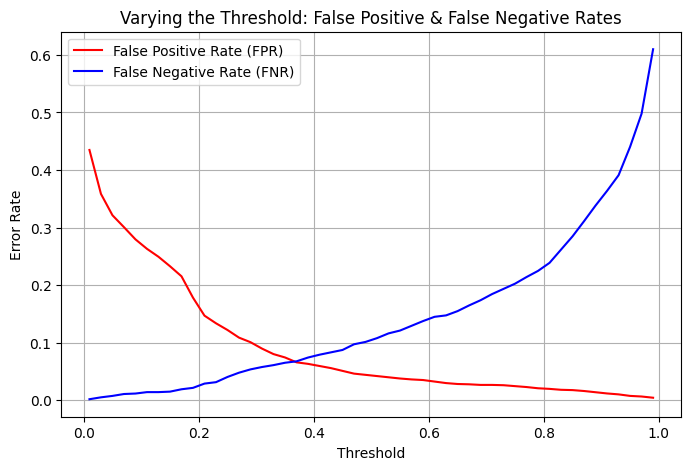

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, fpr_list, label="False Positive Rate (FPR)", color='red')
plt.plot(thresholds, fnr_list, label="False Negative Rate (FNR)", color='blue')
plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("Varying the Threshold: False Positive & False Negative Rates")
plt.legend()
plt.grid()
plt.show()


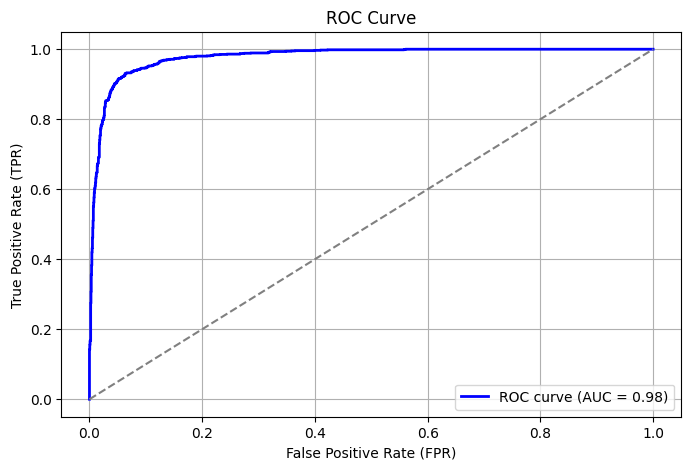

In [130]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve values
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)  # Compute AUC (Area Under Curve)

# Plot ROC Curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")  # Random chance line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [131]:
def newton_method_l2(X, y, lambda_=1, tol=1e-6, max_iter=100):
    """
    Newton's Method for Logistic Regression with L2 Regularization (Ridge)
    """
    beta = np.zeros(X.shape[1])  # Initialize beta as zeros
    for _ in range(max_iter):
        p = predict_prob(X, beta)  # Compute probabilities
        gradient = X.T @ (y - p) - lambda_ * beta  # Add L2 regularization
        W = np.diag(p * (1 - p))  # Weight matrix
        H = X.T @ W @ X + lambda_ * np.identity(X.shape[1])  # Hessian with L2 penalty
        beta_new = beta - np.linalg.inv(H) @ gradient  # Newton-Raphson update
        if np.linalg.norm(beta_new - beta) < tol:  # Convergence check
            break
        beta = beta_new
    return beta


In [133]:
def classify(X, beta):
    return (predict_prob(X, beta) >= 0.7 ).astype(int)

In [134]:
X_test = pd.read_csv('test.csv')
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
X_test

array([[1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.7690e+00, 1.1000e+01,
        6.9000e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.0000e+00,
        1.8000e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.5150e+00, 1.0000e+01,
        1.4400e+02],
       ...,
       [1.0000e+00, 7.7000e-01, 3.8000e-01, ..., 1.4619e+01, 5.2500e+02,
        9.2100e+02],
       [1.0000e+00, 0.0000e+00, 8.9000e-01, ..., 1.8260e+00, 1.0000e+01,
        4.2000e+01],
       [1.0000e+00, 1.3100e+00, 0.0000e+00, ..., 1.2500e+00, 3.0000e+00,
        3.0000e+01]])

In [135]:
prediction = classify(X_test, beta_newton)
prediction = np.where(prediction == 0, 1, 2)
np.count_nonzero(prediction == 1)
# np.savetxt("predictions.txt", prediction, fmt="%d")

977